In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import preliz as pz
import pymc as pm
from cycler import cycler

In [2]:
az.style.use("arviz-darkgrid")
default_cycler = cycler(color=["#000000", "#6a6a6a", "#bebebe", "#2a2eec"])
plt.rc("axes", prop_cycle=default_cycler)
plt.rc("figure", dpi=100)

## Flipping coins the PyMC way

### Code 2.1

In [3]:
np.random.seed(123)
trials = 4
θ_real = 0.35  # unknown in a real experiment
data = pz.Binomial(n=1, p=θ_real).rvs(trials)
data

array([1, 0, 1, 0])

### Code 2.2

In [4]:
with pm.Model() as coin_flip:
    θ = pm.Beta("θ", alpha=1.0, beta=1.0)
    _ = pm.Bernoulli("y", p=θ, observed=data)
    idata_coin = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


### Code 2.3

array([[<Axes: title={'center': 'θ'}>, <Axes: title={'center': 'θ'}>]],
      dtype=object)

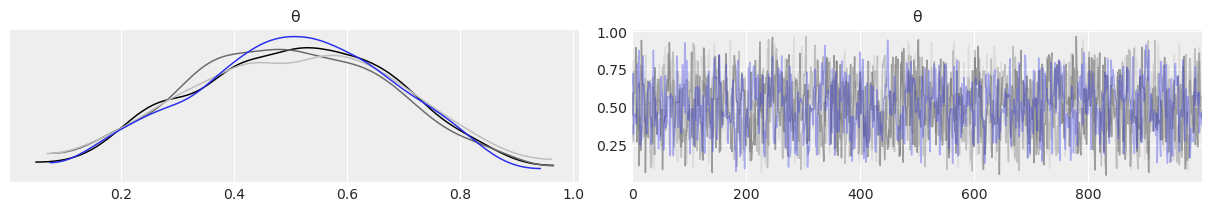

In [5]:
az.plot_trace(idata_coin, compact=False)
# plt.savefig("../images/bbap/bap-02-coin-trace.png")

### Code 2.4

array([[<Axes: title={'center': 'θ'}>,
        <Axes: title={'center': 'θ'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

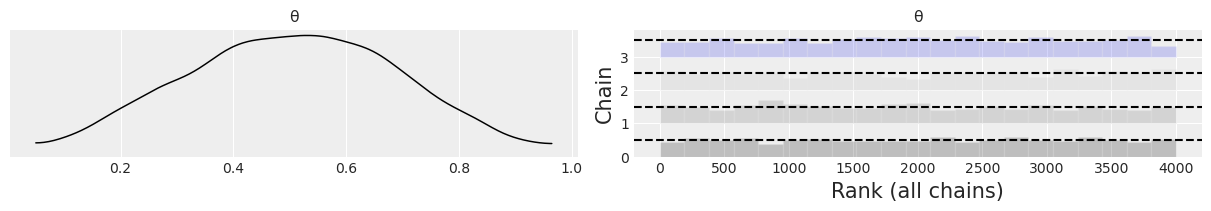

In [6]:
az.plot_trace(idata_coin, kind="rank_bars", combined=True)
# plt.savefig("../images/bbap/bap-02-coin-trace-rank.png")

### Code 2.5

In [7]:
coin_sum = az.summary(idata_coin, kind="stats").round(2)
# coin_sum.to_csv("../python/bap-02-coin.csv")
coin_sum

,mean,sd,hdi_3%,hdi_97%
θ,0.5,0.18,0.18,0.84


## Posterior-based decisions

### Code 2.7

({'BF10': np.float64(0.5098794667650215),
  'BF01': np.float64(1.9612478344040691)},
 <Axes: title={'center': 'The BF_10 is 0.51\nThe BF_01 is 1.96'}, xlabel='θ', ylabel='Density'>)

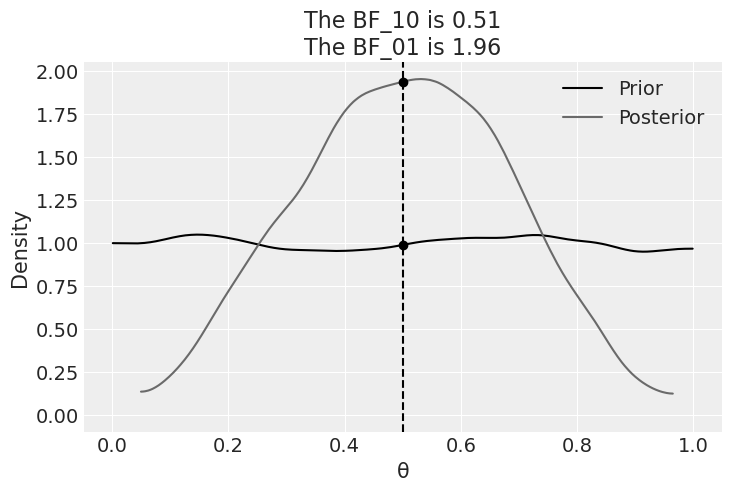

In [8]:
az.plot_bf(idata_coin, ref_val=0.5, var_name="θ", prior=np.random.uniform(0, 1, 10000))
# plt.savefig("../images/bbap/bap-02-coin-trace-bf.png")

<Axes: title={'center': 'θ'}>

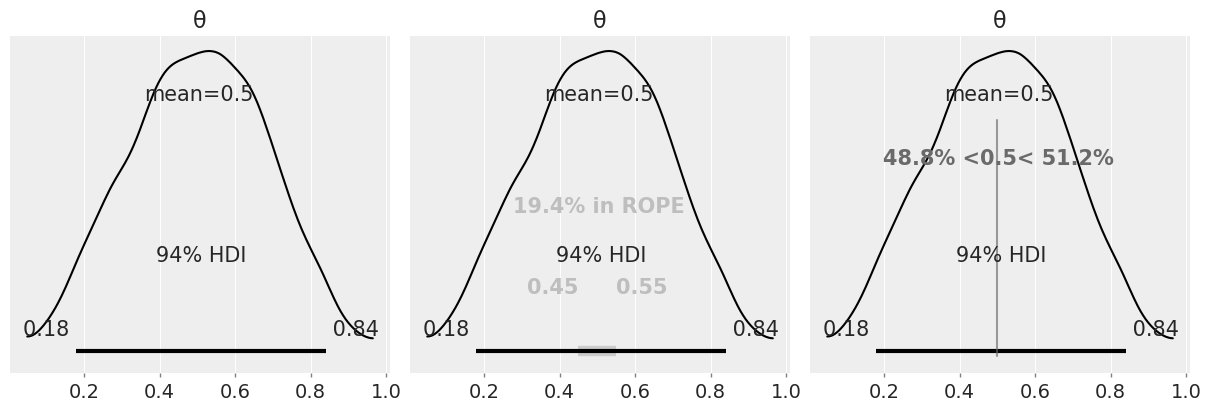

In [9]:
_, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

az.plot_posterior(idata_coin, ax=axes[0])
az.plot_posterior(idata_coin, rope=[0.45, 0.55], ax=axes[1])
az.plot_posterior(idata_coin, ref_val=0.5, ax=axes[2])
# plt.savefig("../images/bbap/bap-02-coin-posterior.png")

### Code 2.10

In [10]:
grid = np.linspace(0, 1, 200)
θ_pos = idata_coin.posterior["θ"]
lossf_mae = [np.mean(abs(i - θ_pos)) for i in grid]
lossf_mse = [np.mean((i - θ_pos) ** 2) for i in grid]
#

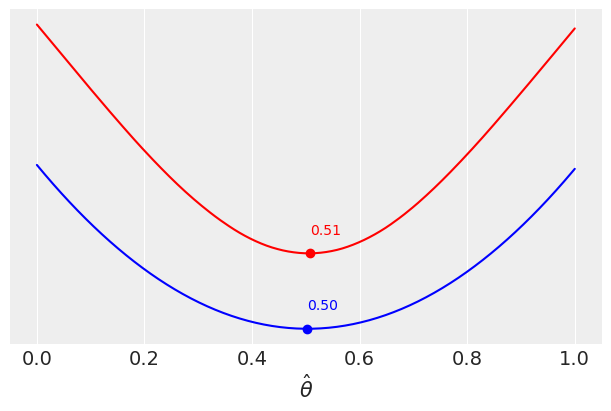

In [11]:
_, ax0 = plt.subplots(figsize=(6, 4))
for lossf, c in zip([lossf_mae, lossf_mse], ["red", "blue"], strict=False):
    mini = np.argmin(lossf)
    ax0.plot(grid, lossf, c)
    ax0.plot(grid[mini], lossf[mini], "o", color=c)
    ax0.annotate(f"{grid[mini]:.2f}", (grid[mini], lossf[mini] + 0.03), color=c)
    ax0.set(xlabel=f"$\\hat{θ}$", yticks=[])


### Code 2.11

[Text(0.5, 0, '$\\hatθ$'), []]

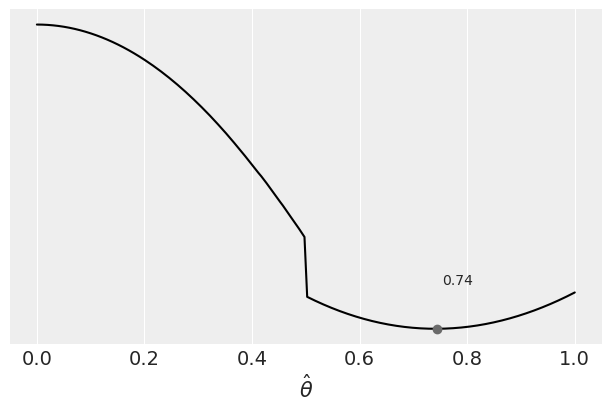

In [12]:
lossf2 = []
for i in grid:
    if i < 0.5:
        f = 1 / np.median(θ_pos / np.abs(i**2 - θ_pos))
    else:
        f = np.mean((i - θ_pos) ** 2 + np.exp(-i)) - 0.25
    lossf2.append(f)
_, ax1 = plt.subplots(figsize=(6, 4))
mini2 = np.argmin(lossf2)
ax1.plot(grid, lossf2)
ax1.plot(grid[mini2], lossf2[mini2], "o")
ax1.annotate(f"{grid[mini2]:.2f}", (grid[mini2] + 0.01, lossf2[mini2] + 0.1))
ax1.set(xlabel=f"$\\hat{θ}$", yticks=[])

{'whiskers': [<matplotlib.lines.Line2D at 0x12fcdc050>,
 'caps': [<matplotlib.lines.Line2D at 0x12fcdc2f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x12cad3e00>],
 'medians': [<matplotlib.lines.Line2D at 0x12fcdc590>],
 'fliers': [<matplotlib.lines.Line2D at 0x12fcdc6e0>],
 'means': []}

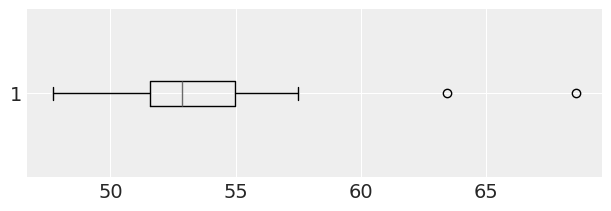

In [13]:
shifts = np.loadtxt("../data/chemical_shifts.csv")
_, ax2 = plt.subplots(figsize=(6, 2))
ax2.boxplot(shifts, vert=False)
# plt.savefig("../images/bbap/bap-02-chem-box.png")

## Gaussians all the way down

### Code 2.12

In [14]:
with pm.Model() as model_g:
    # priors
    μ = pm.Uniform("μ", lower=40, upper=70)
    σ = pm.HalfNormal("σ", sigma=10)
    # likelihood
    pm.Normal("y", mu=μ, sigma=σ, observed=shifts)

    idata_g = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, σ]


/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


array([[<Axes: title={'center': 'μ'}>, <Axes: title={'center': 'μ'}>],
       [<Axes: title={'center': 'σ'}>, <Axes: title={'center': 'σ'}>]],
      dtype=object)

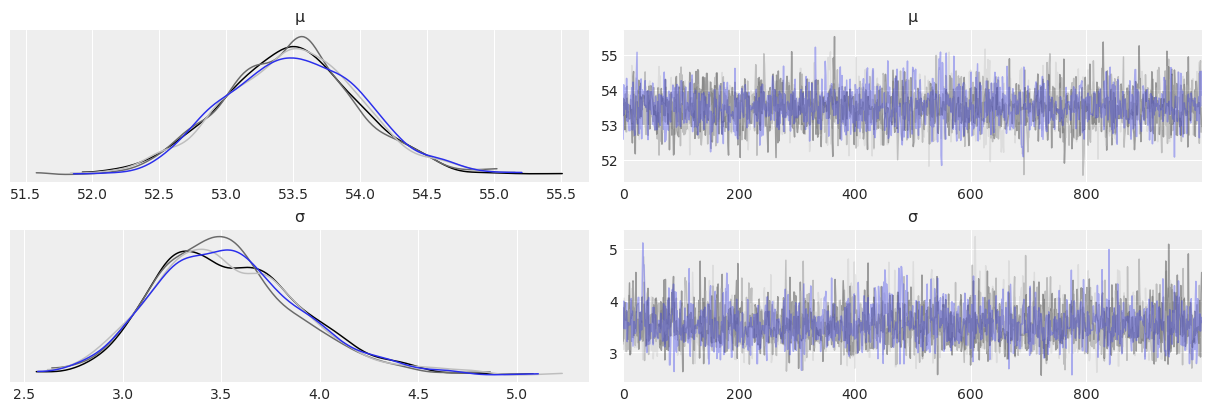

In [15]:
az.plot_trace(idata_g, compact=False)

array([[<Axes: >, None],
       [<Axes: xlabel='μ', ylabel='σ'>, <Axes: >]], dtype=object)

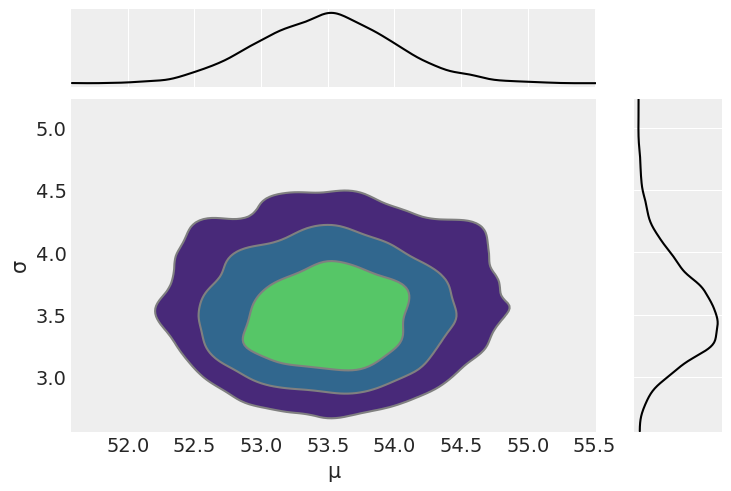

In [16]:
az.plot_pair(idata_g, kind="kde", marginals=True)
# plt.savefig("../images/bbap/bap-02-chem-pair.png")

### Code 2.13

In [17]:
az.summary(idata_g, kind="stats").round(2)

,mean,sd,hdi_3%,hdi_97%
μ,53.49,0.52,52.45,54.4
σ,3.53,0.37,2.83,4.2


## Posterior predictive checks

### Code 2.14

In [18]:
pm.sample_posterior_predictive(
    idata_g, model=model_g, extend_inferencedata=True, random_seed=4591
)

Sampling: [y]


/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

### Code 2.15

<Axes: xlabel='y'>

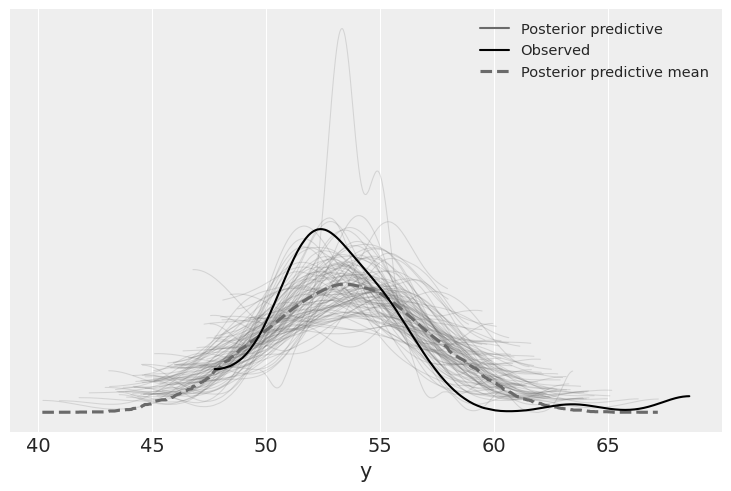

In [19]:
az.plot_ppc(idata_g, num_pp_samples=100, colors=["C1", "C0", "C1"])
# plt.savefig("../images/bbap/bap-02-chem-ppc.png")

## Robust inferences

### Code 2.16

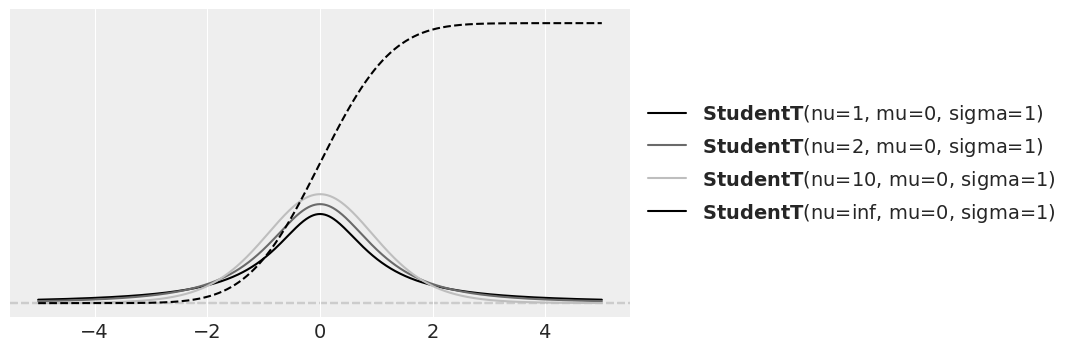

In [20]:
_, ax3 = plt.subplots(figsize=(8, 4))
for nu in [1, 2, 10]:
    pz.StudentT(nu, 0, 1).plot_pdf(support=(-5, 5), ax=ax3)
pz.StudentT(np.inf, 0, 1).plot_pdf(support=(-5, 5), ax=ax3, color="k")
ax3.get_lines()[-1].set_linestyle("--")

In [21]:
with pm.Model() as model_t:
    μ_ = pm.Uniform("μ", 40, 75)
    σ_ = pm.HalfNormal("σ", sigma=10)
    ν = pm.Exponential("ν", 1 / 30)
    _ = pm.StudentT("y", mu=μ_, sigma=σ_, nu=ν, observed=shifts)

    idata_t = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, σ, ν]


/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


array([[<Axes: title={'center': 'μ'}>, <Axes: title={'center': 'μ'}>],
       [<Axes: title={'center': 'σ'}>, <Axes: title={'center': 'σ'}>],
       [<Axes: title={'center': 'ν'}>, <Axes: title={'center': 'ν'}>]],
      dtype=object)

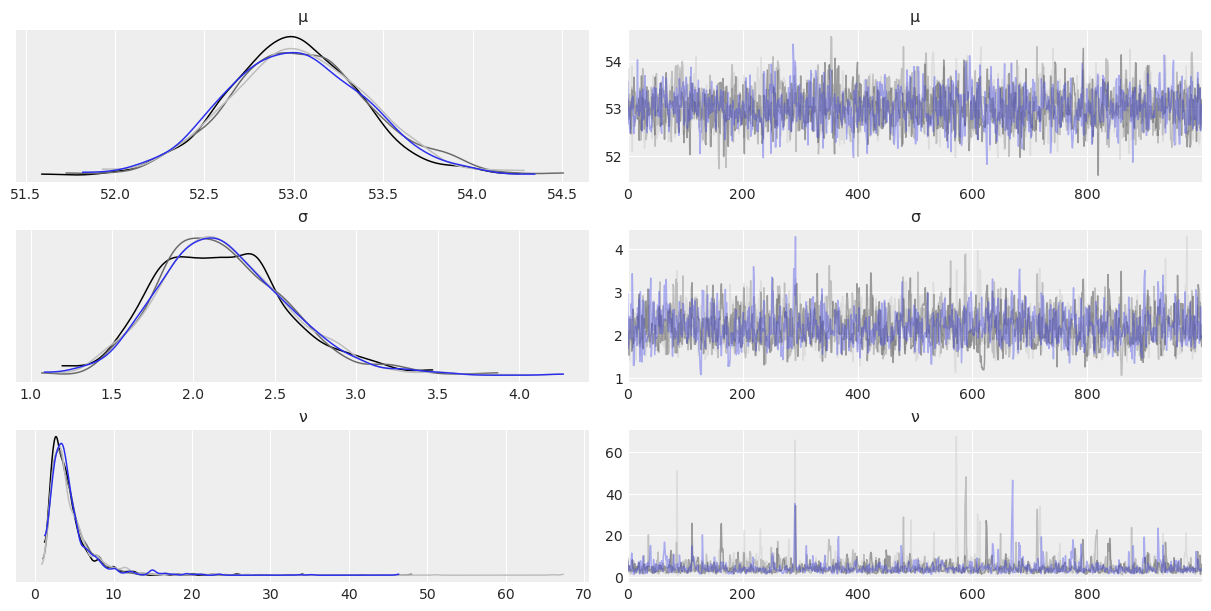

In [22]:
az.plot_trace(idata_t, compact=False)

In [23]:
az.summary(idata_t, kind="stats").round(2)

,mean,sd,hdi_3%,hdi_97%
μ,53.02,0.39,52.24,53.70
σ,2.18,0.40,1.49,2.93
ν,4.57,3.72,1.17,9.30


Sampling: [y]


/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[(40.0, 70.0)]

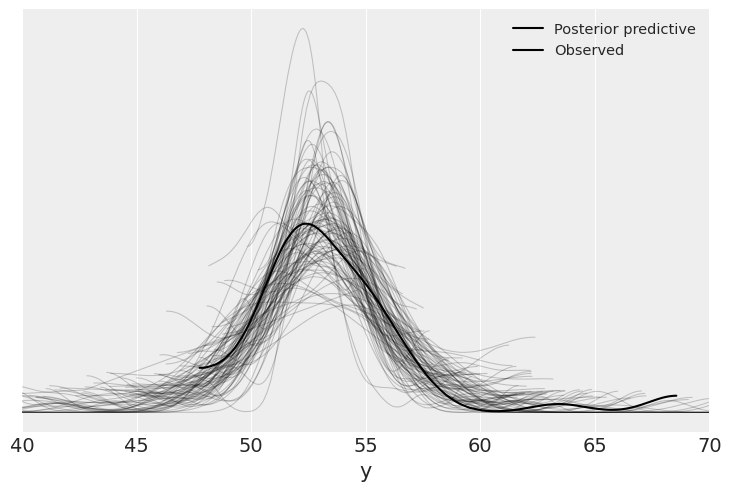

In [24]:
pm.sample_posterior_predictive(
    idata_t, model=model_t, extend_inferencedata=True, random_seed=123
)
ax = az.plot_ppc(idata_t, mean=False, num_pp_samples=100)
ax.set(xlim=(40, 70))